gamma: 2.0


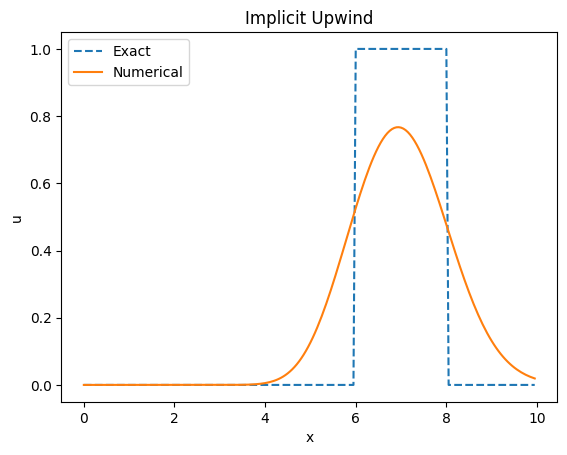

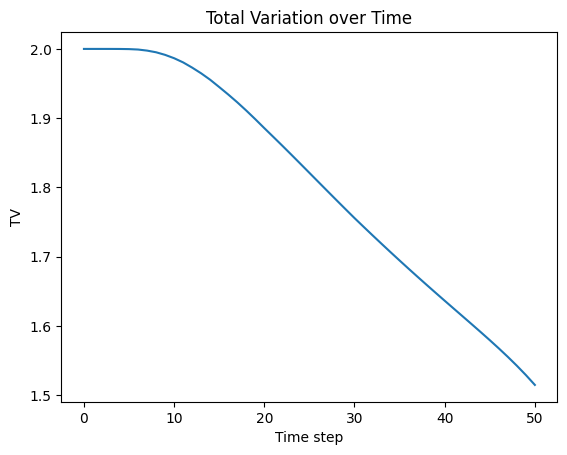

In [6]:
import numpy as np
import matplotlib.pyplot as plt


L = 10.0          
T = 5.0          
Nx = 200          
dx = L / Nx
dt = dx*2.0        
Nt = int(T / dt)
gamma = dt / dx   

print('gamma:', gamma)

x = np.linspace(0, L, Nx, endpoint=False)

u = np.zeros(Nx)
u[(x >= 1) & (x <= 3)] = 1.0

def exact_solution(x, t):
    return ((x - t) >= 1) & ((x - t) <= 3)

# Total variation
def totvar(y):
    tv = 0.0
    for i in range(1, len(y)):
        tv += abs(y[i] - y[i-1])
    return tv


tv_values = [totvar(u)]

for n in range(Nt):
    u_new = np.zeros_like(u)

    u_new[0] = (u[0] + gamma * u_new[-1]) / (1 + gamma)
    
    for i in range(1, Nx):
        u_new[i] = (u[i] + gamma * u_new[i-1]) / (1 + gamma)

    u_new[-1] = (u[-1] + gamma * u_new[-2]) / (1 + gamma)

    u = u_new.copy()
    tv_values.append(totvar(u))

u_exact = exact_solution(x, T)

plt.figure()
plt.plot(x, u_exact, label="Exact", linestyle="--")
plt.plot(x, u, label="Numerical")
plt.legend()
plt.title("Implicit Upwind")
plt.xlabel("x")
plt.ylabel("u")
plt.show()

plt.figure()
plt.plot(tv_values)
plt.title("Total Variation over Time")
plt.xlabel("Time step")
plt.ylabel("TV")
plt.show()